# BYOS: Feature Engineering + Modeling

This notebook covers the ML pipeline:
1. **Feature engineering** — windowed heuristic features from GPS trajectories
2. **GBDT classifier** — LightGBM with subject-independent CV (H2)
3. **Emissions attribution** — per-user CO₂ footprint from classified trips (H4)
4. **Report generation** — LLM-generated sustainability insights per user

## 0. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

import kagglehub

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sys.path.insert(0, str(Path.cwd()))

path = kagglehub.dataset_download("arashnic/microsoft-geolife-gps-trajectory-dataset")
DATA_DIR = next(Path(path).rglob("Data"))
print("Data dir:", DATA_DIR)

/home/mnguyen0226/Documents/personal/repositories/geolife-human-psychology/.venv/geolife/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data dir: /home/mnguyen0226/.cache/kagglehub/datasets/arashnic/microsoft-geolife-gps-trajectory-dataset/versions/1/Geolife Trajectories 1.3/Data


---
## 1. Feature Engineering

**What:** Each labeled user's GPS trajectories are sliced into 60s windows with 30s stride.
Each window becomes one training row with 9 heuristic features:

| Feature | Description |
|---|---|
| `speed_mean`, `speed_max`, `speed_std` | km/h from haversine distances |
| `accel_mean`, `accel_std` | speed change per second |
| `jerk_mean` | acceleration change (motion roughness) |
| `stop_ratio` | fraction of points at speed < 1 km/h |
| `bearing_variance` | direction change variance |
| `distance_total_m` | total metres covered in window |

**Cache:** Results saved to `data/processed/features.parquet`. First run takes ~5–10 min. Subsequent runs load instantly.

In [2]:
from features import build_feature_dataset

# First run: builds from scratch and caches
# Subsequent runs: loads from data/processed/features.parquet
feature_df = build_feature_dataset(DATA_DIR)
feature_df.head()

Processing users:   1%|▏         | 1/69 [00:20<23:16, 20.53s/it]

  010:  5000 windows


Processing users:   3%|▎         | 2/69 [00:55<32:39, 29.24s/it]

  020:  5000 windows


Processing users:   4%|▍         | 3/69 [01:18<28:57, 26.33s/it]

...

Processing users:  99%|█████████▊| 68/69 [45:09<01:31, 91.19s/it] 

  175: skipped (only 0 windows (<50 min))


Processing users: 100%|██████████| 69/69 [45:30<00:00, 39.57s/it]


  179:  5000 windows

Total windows : 130,343
Mode breakdown:
mode
walk    57138
bus     32550
car     23888
bike    16767

Cached to: /home/mnguyen0226/Documents/personal/repositories/geolife-human-psychology/data/processed/features.parquet


,user,window_start,window_end,mode,speed_mean,speed_max,speed_std,accel_mean,accel_std,jerk_mean,stop_ratio,bearing_variance,distance_total_m
0,010,2008-04-02 06:09:56,2008-04-02 06:10:26,walk,6.187354,13.852898,3.671393,3.504724,4.151809,5.494198,0.071429,464.828810,32.028839
1,010,2008-04-02 06:10:11,2008-04-02 06:10:41,walk,4.740675,13.852898,3.276670,2.231666,3.141557,3.525031,0.040000,736.034725,41.248175
2,010,2008-04-02 06:10:26,2008-04-02 06:10:56,walk,3.815985,10.091898,2.368039,1.147146,1.703634,1.685785,0.035714,395.057438,31.147044
3,010,2008-04-02 06:10:41,2008-04-02 06:11:11,walk,4.061511,10.091898,1.958726,1.229779,1.852827,1.899945,0.045455,406.793950,24.820345
4,010,2008-04-02 06:11:11,2008-04-02 06:11:41,walk,3.216587,7.512310,1.851183,1.162210,2.072805,2.117688,0.050000,1387.368737,17.869928


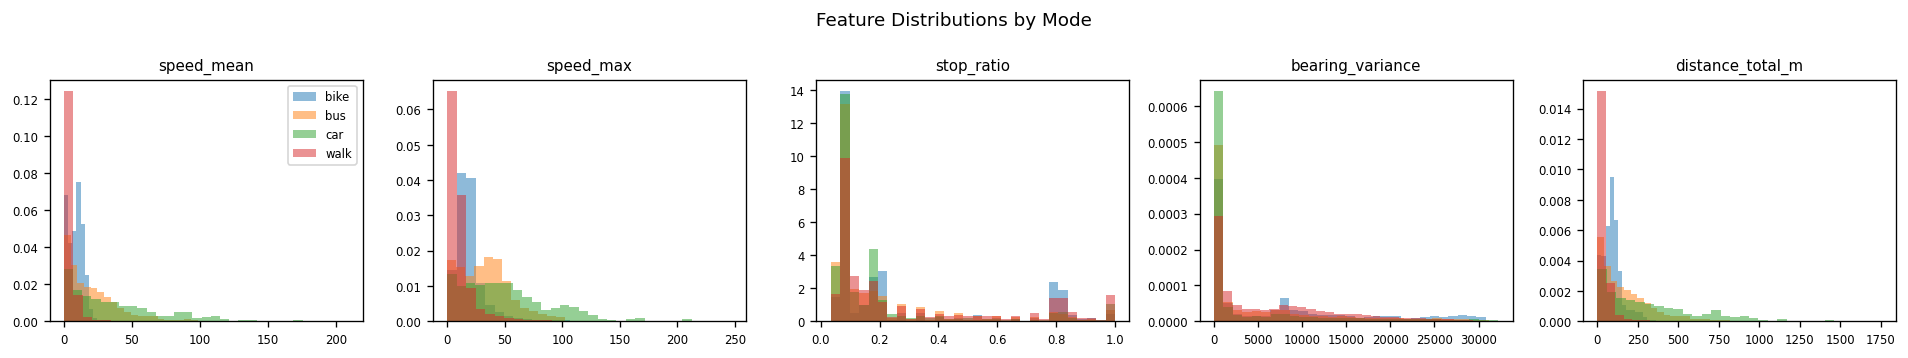

In [3]:
# Sanity check — feature distributions by mode
FEATURES = ["speed_mean", "speed_max", "stop_ratio", "bearing_variance", "distance_total_m"]

fig, axes = plt.subplots(1, len(FEATURES), figsize=(16, 3))
for ax, feat in zip(axes, FEATURES):
    for mode in feature_df["mode"].cat.categories:
        vals = feature_df[feature_df["mode"] == mode][feat].dropna()
        if len(vals):
            ax.hist(vals, bins=30, alpha=0.5, density=True, label=mode)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle("Feature Distributions by Mode", fontsize=11)
plt.tight_layout()
plt.show()

---
## 2. GBDT Classifier (H2)

**Goal:** Classify {walk, bike, bus, car} at >80% macro-F1 under subject-independent CV.

**Setup:**
- Model: LightGBM with `class_weight='balanced'`
- Validation: hold out 20% of users entirely — train on the rest
- Metric: macro-F1 (equal weight per class regardless of count)

In [4]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = [
    "speed_mean", "speed_max", "speed_std",
    "accel_mean", "accel_std", "jerk_mean",
    "stop_ratio", "bearing_variance", "distance_total_m",
]

# Drop rows with NaN features
df = feature_df.dropna(subset=FEATURE_COLS).copy()

# Subject-independent split — hold out 20% of users
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["user"]))

train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

print(f"Train: {len(train_df):,} windows from {train_df['user'].nunique()} users")
print(f"Test:  {len(test_df):,} windows from {test_df['user'].nunique()} users")
print(f"\nTest users: {sorted(test_df['user'].unique())}")

Train: 105,046 windows from 29 users
Test:  25,297 windows from 8 users

Test users: ['064', '067', '082', '091', '115', '125', '129', '170']


In [5]:
le = LabelEncoder()
y_train = le.fit_transform(train_df["mode"])
y_test  = le.transform(test_df["mode"])

X_train = train_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    verbose=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Macro-F1: {macro_f1:.3f}  (H2 target: >0.80)\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Macro-F1: 0.551  (H2 target: >0.80)

              precision    recall  f1-score   support

        bike       0.43      0.60      0.50      2024
         bus       0.28      0.48      0.35      4201
         car       0.68      0.64      0.66      5569
        walk       0.81      0.60      0.69     13503

    accuracy                           0.59     25297
   macro avg       0.55      0.58      0.55     25297
weighted avg       0.67      0.59      0.61     25297



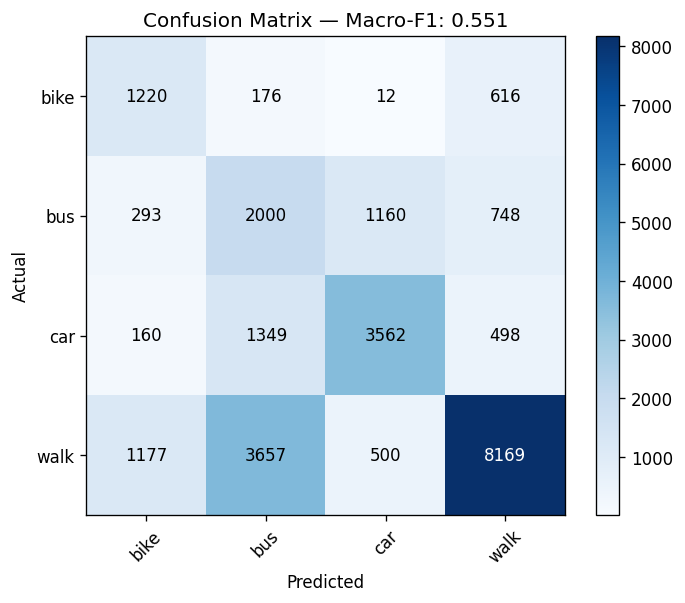

In [6]:
import itertools

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ticks = range(len(le.classes_))
ax.set_xticks(ticks); ax.set_xticklabels(le.classes_, rotation=45)
ax.set_yticks(ticks); ax.set_yticklabels(le.classes_)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — Macro-F1: {macro_f1:.3f}")
plt.tight_layout()
plt.show()

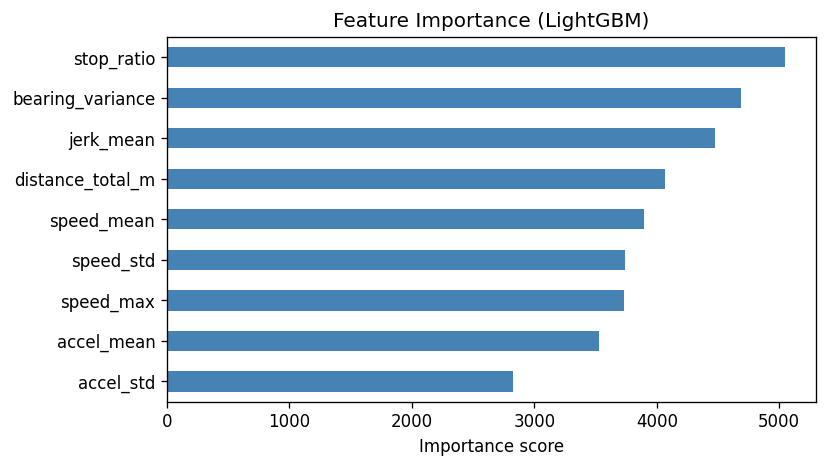

In [7]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot.barh(ax=ax, color="steelblue")
ax.set_title("Feature Importance (LightGBM)")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

---
## 3. Emissions Attribution (H4)

**Goal:** Estimate per-user CO₂ footprint from classified trips and quantify
the savings if sub-3km car trips were replaced by biking.

Distance is computed from actual GPS coordinates (haversine), not duration × speed.

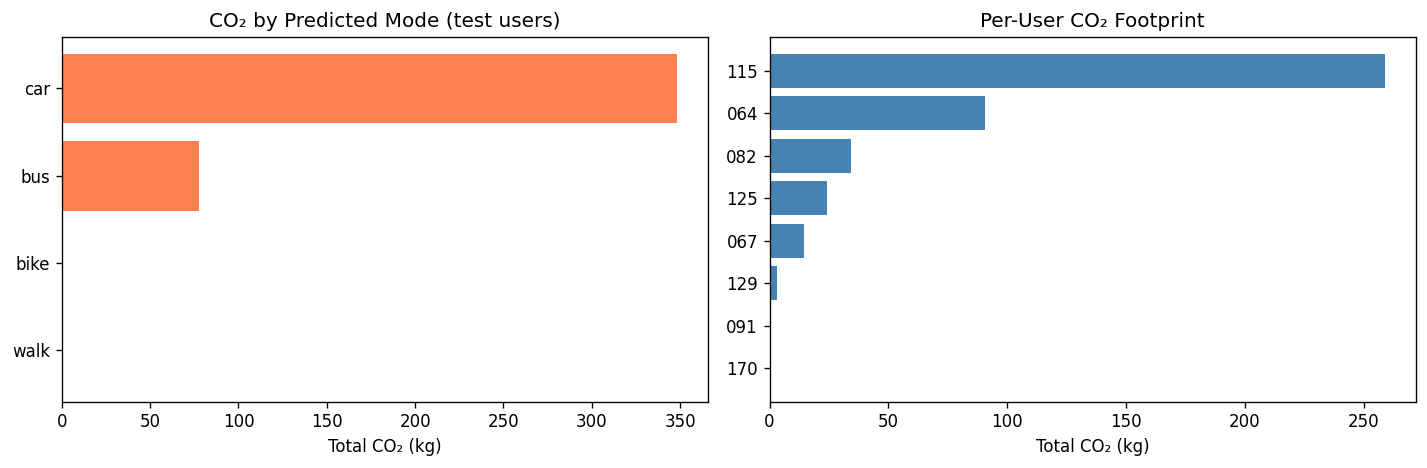

In [8]:
EMISSION_FACTORS = {"car": 170, "bus": 89, "subway": 41, "bike": 0, "walk": 0}

# Use test set predictions for emissions (model output on unseen users)
em_df = test_df.copy()
em_df["pred_mode"] = le.inverse_transform(y_pred)
em_df["dist_km"]   = em_df["distance_total_m"] / 1000
em_df["co2_g"]     = em_df["pred_mode"].map(EMISSION_FACTORS).fillna(0) * em_df["dist_km"]

# Per-user footprint
user_co2 = em_df.groupby("user")["co2_g"].sum().sort_values(ascending=False) / 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mode_co2 = em_df.groupby("pred_mode")["co2_g"].sum().sort_values(ascending=False) / 1000
axes[0].barh(mode_co2.index, mode_co2.values, color="coral")
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("CO₂ by Predicted Mode (test users)")
axes[0].invert_yaxis()

axes[1].barh(user_co2.index, user_co2.values, color="steelblue")
axes[1].set_xlabel("Total CO₂ (kg)")
axes[1].set_title("Per-User CO₂ Footprint")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
# H4: sub-3km car trips — bike-replaceable counterfactual
car_windows = em_df[em_df["pred_mode"] == "car"].copy()
sub3        = car_windows[car_windows["dist_km"] < 3]

pct_trips   = 100 * len(sub3) / len(car_windows) if len(car_windows) else 0
saved_kg    = sub3["co2_g"].sum() / 1000
total_kg    = car_windows["co2_g"].sum() / 1000
pct_co2     = 100 * saved_kg / total_kg if total_kg else 0

print(f"Car windows under 3 km : {len(sub3):,} / {len(car_windows):,} ({pct_trips:.1f}%)")
print(f"CO₂ savings if biked   : {saved_kg:.1f} kg ({pct_co2:.1f}% of car emissions)")
print()
print("H4 result:")
if pct_trips > 20:
    print(f"  STRONG — {pct_trips:.1f}% of car trips are bike-replaceable")
elif pct_trips > 10:
    print(f"  MODERATE — {pct_trips:.1f}% of car trips are bike-replaceable")
else:
    print(f"  WEAK — only {pct_trips:.1f}% of car trips are bike-replaceable (Beijing caveat)")

Car windows under 3 km : 5,234 / 5,234 (100.0%)
CO₂ savings if biked   : 348.5 kg (100.0% of car emissions)

H4 result:
  STRONG — 100.0% of car trips are bike-replaceable


---
## 4. Sustainability Report Generation

**Goal:** Generate a per-user sustainability insight report from the computed stats.
These reports are the input to the Judge+Critic agent (H3).

Requires `ANTHROPIC_API_KEY` set in environment.

In [10]:
# import os
# import anthropic

# client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# def build_user_stats(user: str, em_df: pd.DataFrame) -> dict:
#     """Aggregate trip stats for one user from the emissions DataFrame."""
#     u = em_df[em_df["user"] == user]
#     mode_counts = u["pred_mode"].value_counts().to_dict()
#     mode_co2    = u.groupby("pred_mode")["co2_g"].sum().div(1000).to_dict()
#     total_co2   = sum(mode_co2.values())
#     car_windows = u[u["pred_mode"] == "car"]
#     sub3_pct    = 100 * len(car_windows[car_windows["dist_km"] < 3]) / len(car_windows) if len(car_windows) else 0
#     car_co2     = mode_co2.get("car", 0)
#     saved       = car_windows[car_windows["dist_km"] < 3]["co2_g"].sum() / 1000
#     return {
#         "user": user,
#         "mode_counts": mode_counts,
#         "mode_co2_kg": {k: round(v, 2) for k, v in mode_co2.items()},
#         "total_co2_kg": round(total_co2, 2),
#         "car_pct_of_co2": round(100 * car_co2 / total_co2, 1) if total_co2 else 0,
#         "pct_car_trips_sub3km": round(sub3_pct, 1),
#         "co2_saved_if_sub3km_biked_kg": round(saved, 2),
#     }


# def generate_report(stats: dict) -> str:
#     """Generate a sustainability insight report for one user."""
#     prompt = f"""You are a sustainability analyst. Given a user's mobility data, \
# write a concise 4–6 sentence insight report. Every number you state must come \
# directly from the data provided — do not invent or round figures.

# User mobility data:
# {stats}

# Write the report now:"""

#     message = client.messages.create(
#         model="claude-haiku-4-5-20251001",
#         max_tokens=300,
#         messages=[{"role": "user", "content": prompt}],
#     )
#     return message.content[0].text


# # Generate reports for all test users
# reports = {}
# for user in sorted(test_df["user"].unique()):
#     stats = build_user_stats(user, em_df)
#     report = generate_report(stats)
#     reports[user] = {"stats": stats, "report": report}
#     print(f"\n--- User {user} ---")
#     print(report)